# ECG heartbeat classification — baselines, CNN, LSTM, and CNN–Transformer

**Problem:** Given one already extracted electrocardiogram (ECG) beat, predict its grouped beat label: **N, S, V, F, or Q**. Each row represents one beat, not one person. The clinical motivation is to help review recorded heart rhythms; this notebook performs an educational *beat-label classification* task and does not diagnose a patient.

**Learning objectives**

1. Separate model development from final testing.
2. Explain why a majority-class reference is weak despite high accuracy.
3. Train a multiclass logistic-regression baseline, a one-dimensional convolutional neural network (1D CNN), a plain long short-term memory (LSTM) model, and a CNN–Transformer encoder.
4. Compare the models with the same validation split and interpret class-level errors.
5. Optionally track configurations and validation metrics in Weights & Biases (W&B).

**Prerequisites:** introductory Python, NumPy arrays, supervised classification, and the [concepts](ecg_hb_clf.ipynb) and [EDA](ecg_hb_clf_eda.ipynb) notebooks. This is a focused lecture example, not a full lab. It aligns with Unit II (clinical applications, CO2) and Unit IV (model validation, CO4).

**Contents:** 1. Evaluation plan · 2. Load and check data · 3. Validation split · 4. Majority-class reference · 5. Logistic regression · 6. Baseline errors · 7. 1D CNN · 8. Plain LSTM · 9. CNN–Transformer encoder · 10. Compare models · 11. Existing CNN test benchmark · 12. Interpretation and limitations.

## 1. What will we predict, and how will we evaluate it?

| Item | Choice for this notebook |
|---|---|
| Model input | The 187 ordered, processed waveform values in one CSV row |
| Target | The final CSV value: 0=N, 1=S, 2=V, 3=F, 4=Q |
| Unit of analysis | One extracted beat; several beats can come from one person |
| Decision time | After an ECG segment has been recorded and a beat extracted |
| Intended use | Compare educational classification methods, not make a clinical decision |

**Evaluation sequence**

1. Keep the supplied `mitbih_test.csv` for one final evaluation.
2. Split the supplied training file into a **fit** subset and a **validation** subset. *Stratified* means preserving approximately the same five-class proportions in both subsets.
3. Fit a majority-class reference, weighted logistic regression, a small 1D CNN, a plain LSTM, and a CNN–Transformer on the **same fit subset**.
4. Compare validation **macro F1** and class-level errors. The CNN test result was viewed before adding the LSTM, so we keep it as an existing benchmark. The LSTM and CNN–Transformer comparisons are exploratory; we do not select them using the supplied test file.

**Important limit:** the CSVs contain no patient or recording identifiers. We cannot verify that beats from one person are separated across subsets. A beat-level split therefore cannot establish performance on new patients. [Original MIT-BIH database](https://physionet.org/content/mitdb/1.0.0/) · [processed dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat).

## 2. Load the processed beat files

**Data setup**

1. On Kaggle, attach [ECG Heartbeat Categorization Dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat) using **Add Input**. This notebook looks for `mitbih_train.csv` and `mitbih_test.csv` under `/kaggle/input/`.
2. Locally, keep those files at `module2/lectures/data/ecg_hb_clf/`. Run this notebook from its folder or the repository root.
3. Dependencies: **NumPy, pandas, scikit-learn, matplotlib, IPython, and PyTorch**. No installation or download cell runs automatically. The two MIT-BIH CSVs total roughly **515 MB**; the CNN runs on CPU or uses a Kaggle GPU when enabled. Runtime depends on hardware, and the full training files must fit in memory. The Kaggle card lists the dataset license as **unknown**; use the attached input for the exercise and check permissions before redistributing the files.

**Optional experiment tracking with Weights & Biases (W&B)**

1. Install the `wandb` Python package in your environment before starting the notebook if you want tracking. It is an optional dependency; the notebook does not install it automatically.
2. Supply your W&B API key through your environment or Kaggle Secrets, then set `USE_WANDB = True` in the next code cell. Do not paste a key into the notebook. W&B creates separate runs in project `ecg_hb_clf` for the majority reference, logistic regression, CNN, LSTM, and CNN–Transformer.
3. Each run records its configuration and aggregate validation metrics. The neural runs also record one point per epoch and the best validation epoch. Raw ECG signals, individual predictions, and model weights are not uploaded by this notebook. The existing saved outputs predate W&B integration; no W&B runs have been created by this edit.

[W&B experiment tracking documentation](https://docs.wandb.ai/models/track) · [W&B Python run API](https://docs.wandb.ai/ref/python/experiments/run/).

The source preprocessing already extracted, resampled, normalized, and padded beats. We therefore **do not resample or detect R-peaks again**. The 187 values are processed signal magnitudes, not millivolt readings. The last column is the label and must not enter the model. [Source paper](https://arxiv.org/pdf/1805.00794) · [dataset card](https://www.kaggle.com/datasets/shayanfazeli/heartbeat).

In [12]:
from pathlib import Path
from contextlib import nullcontext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             confusion_matrix, f1_score, precision_recall_fscore_support)
from sklearn.model_selection import train_test_split

SEED = 42
CLASS_IDS = np.arange(5)
CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']
USE_WANDB = True  # Change to True after installing wandb and configuring your API key.
WANDB_PROJECT = 'ecg_hb_clf'

def tracked_run(model_name, config):
    if not USE_WANDB:
        return nullcontext(None)
    import wandb
    return wandb.init(
        project=WANDB_PROJECT,
        name=model_name,
        config={
            'model': model_name,
            'dataset': 'ECG Heartbeat Categorization Dataset / MIT-BIH',
            'split_seed': SEED,
            'validation_fraction': 0.20,
            'input_values': 187,
            **config,
        },
    )
LOCAL_CANDIDATES = [Path('../data/ecg_hb_clf'), Path('module2/lectures/data/ecg_hb_clf')]
KAGGLE_ROOT = Path('/kaggle/input')
if KAGGLE_ROOT.is_dir():
    kaggle_candidates = sorted({q.parent for q in KAGGLE_ROOT.rglob('mitbih_train.csv')
                                if (q.parent / 'mitbih_test.csv').is_file()})
    if len(kaggle_candidates) > 1:
        raise ValueError(f'Multiple MIT-BIH datasets found: {kaggle_candidates}. Select one explicitly.')
else:
    kaggle_candidates = []
DATA_DIR = next((q for q in kaggle_candidates + LOCAL_CANDIDATES
                 if (q / 'mitbih_train.csv').is_file()
                 and (q / 'mitbih_test.csv').is_file()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Attach the Kaggle heartbeat dataset or place both MIT-BIH CSVs in module2/lectures/data/ecg_hb_clf/.')

train_df = pd.read_csv(DATA_DIR / 'mitbih_train.csv', header=None, dtype=np.float32)
print('Data folder:', DATA_DIR)
print(f'Supplied training file: {train_df.shape}')

Data folder: /kaggle/input/datasets/shayanfazeli/heartbeat
Supplied training file: (87554, 188)


In [13]:
import torch

if torch.cuda.is_available():
    print("Number of GPUs:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    print("No GPU detected; the notebook is running on CPU.")

Number of GPUs: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [ ]:
if USE_WANDB:
    import wandb
    wandb.login()

### Check model inputs before fitting

We require exactly **188 columns**: 187 signal positions plus one label. The checks below stop rather than silently dropping rows if a signal is non-finite or a label is outside 0–4. The test file is loaded only in the final evaluation section.

In [18]:
def split_signal_and_label(df, file_name):
    if df.shape[1] != 188:
        raise ValueError(f'{file_name}: expected 188 columns, got {df.shape[1]}')
    X = df.iloc[:, :187].to_numpy(dtype=np.float32, copy=True)
    labels = df.iloc[:, 187].to_numpy(copy=True)
    if not np.isfinite(X).all() or not np.isfinite(labels).all():
        raise ValueError(f'{file_name}: non-finite values found')
    if not np.isin(labels, CLASS_IDS).all():
        raise ValueError(f'{file_name}: expected only labels 0, 1, 2, 3, 4')
    return X, labels.astype(np.int8)

X_train_all, y_train_all = split_signal_and_label(train_df, 'train')
display(pd.DataFrame({'class': CLASS_NAMES,
                      'training_beats': np.bincount(y_train_all, minlength=5)}))
print('Signal values in training file:', float(X_train_all.min()), 'to', float(X_train_all.max()))

,class,training_beats
0,N,72471
1,S,2223
2,V,5788
3,F,641
4,Q,6431


Signal values in training file: 0.0 to 1.0


## 3. Create a validation subset

We hold out **20% of the supplied training beats** for validation. `random_state` makes this classroom split reproducible; `stratify` maintains the label proportions. The supplied test file remains separate. Without patient IDs, this split is only an internal beat-level check.

In [19]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train_all, y_train_all, test_size=0.20,
    stratify=y_train_all, random_state=SEED,
)
display(pd.DataFrame({
    'class': CLASS_NAMES,
    'fit_beats': np.bincount(y_fit, minlength=5),
    'validation_beats': np.bincount(y_val, minlength=5),
}))
print('Fit rows:', len(y_fit), '| validation rows:', len(y_val))

,class,fit_beats,validation_beats
0,N,57977,14494
1,S,1778,445
2,V,4630,1158
3,F,513,128
4,Q,5145,1286


Fit rows: 70043 | validation rows: 17511


## 4. Reference baseline: always predict the most common class

`DummyClassifier(strategy="most_frequent")` learns only which label occurs most often in the fit subset. It ignores waveform shape. Here that label is usually **N**. Its accuracy can be high because N dominates the dataset, even though it misses every non-N beat.

We will report:

- **Accuracy:** fraction of all beats predicted correctly.
- **Balanced accuracy:** average recall across the five classes. Recall for a class is the fraction of that class's actual beats found.
- **Macro F1:** average of the five class F1 scores, defined below. [Metric definitions](https://scikit-learn.org/stable/modules/model_evaluation.html).

**Macro F1 is our main validation metric.** For each class $c$, calculate F1 from precision $P_c$ (correct predictions among beats predicted as $c$) and recall $R_c$ (correct predictions among actual beats of $c$), then average the five class scores:

$$F1_c = \frac{2P_cR_c}{P_c+R_c}, \qquad \text{macro F1} = \frac{1}{5}\sum_{c \in \{N,S,V,F,Q\}} F1_c.$$

Each class contributes equally even though N has many more beats. A model that predicts only N therefore scores poorly on macro F1 despite high accuracy. We use validation macro F1 to compare models and select the best CNN and LSTM training epochs. We also inspect balanced accuracy, per-class precision and recall, support, and the confusion matrix to understand specific errors. If a class's F1 is undefined, this notebook records it as 0 (`zero_division=0`).

In [20]:
def summary_row(name, truth, prediction):
    return {
        'model': name,
        'accuracy': accuracy_score(truth, prediction),
        'balanced_accuracy': balanced_accuracy_score(truth, prediction),
        'macro_F1': f1_score(truth, prediction, labels=CLASS_IDS,
                             average='macro', zero_division=0),
    }

def validation_tracking_metrics(truth, prediction):
    row = summary_row('', truth, prediction)
    precision, recall, f1, support = precision_recall_fscore_support(
        truth, prediction, labels=CLASS_IDS, zero_division=0,
    )
    metrics = {
        'val/accuracy': float(row['accuracy']),
        'val/balanced_accuracy': float(row['balanced_accuracy']),
        'val/macro_F1': float(row['macro_F1']),
    }
    for name, p, r, score, count in zip(CLASS_NAMES, precision, recall, f1, support):
        metrics[f'val/precision_{name}'] = float(p)
        metrics[f'val/recall_{name}'] = float(r)
        metrics[f'val/F1_{name}'] = float(score)
        metrics[f'val/support_{name}'] = int(count)
    return metrics

dummy = DummyClassifier(strategy='most_frequent')
with tracked_run('Majority reference', {'strategy': 'most_frequent'}) as run:
    dummy.fit(X_fit, y_fit)
    dummy_val_pred = dummy.predict(X_val)
    if run is not None:
        run.log(validation_tracking_metrics(y_val, dummy_val_pred))
display(pd.DataFrame([summary_row('Always majority class', y_val, dummy_val_pred)]).round(3))
print('Predicted class:', CLASS_NAMES[int(dummy_val_pred[0])])

val/F1_F,▁
val/F1_N,▁
val/F1_Q,▁
val/F1_S,▁
val/F1_V,▁
val/accuracy,▁
val/balanced_accuracy,▁
val/macro_F1,▁
val/precision_F,▁
val/precision_N,▁
+13,...


,model,accuracy,balanced_accuracy,macro_F1
0,Always majority class,0.828,0.2,0.181


Predicted class: N


## 5. Model baseline: multiclass logistic regression

The classifier learns one weight for each waveform position (for each class) and combines the 187 values to produce class scores. It is a **linear** baseline: it cannot automatically learn complex local waveform patterns as a convolutional neural network might.

We use `class_weight="balanced"` because the fit subset has far fewer S and F beats than N beats. The weights are computed **from the fit labels only**; they give errors on rare classes more influence during fitting. This can improve rare-class recall while also producing more false alarms, so we inspect both precision and recall. [Scikit-learn logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

### How `class_weight="balanced"` sets and uses the weights

1. **Calculate one weight per class.** For class $c$, scikit-learn uses

   $$w_c = \frac{n_\text{samples}}{n_\text{classes} \times n_c},$$

   where $n_\text{samples}$ is the number of fit beats, $n_\text{classes} = 5$, and $n_c$ is the number of fit beats in class $c$. Rarer classes therefore receive larger weights. [compute_class_weight](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html).

2. **Example with the fit counts from Section 3.** There are 70,043 fit beats, so $n_\text{samples}/n_\text{classes} = 70{,}043 / 5 \approx 14{,}009$.

   | Class | Fit beats $n_c$ | Weight $w_c$ | $n_c \times w_c$ |
   |---|---|---|---|
   | N | 57,977 | 0.242 | 14,009 |
   | S | 1,778 | 7.879 | 14,009 |
   | V | 4,630 | 3.026 | 14,009 |
   | F | 513 | 27.307 | 14,009 |
   | Q | 5,145 | 2.723 | 14,009 |

   Each class now has the **same total weight** in the loss. One misclassified F beat counts about $27.3 / 0.242 \approx 113$ times as much as one misclassified N beat.

3. **Use the weights in the loss.** Logistic regression minimizes cross-entropy loss plus its default L2 penalty. Each beat's loss term is multiplied by the weight of its *true* class:

   $$\text{Loss} = -\sum_{i=1}^{n} w_{y_i}\,\log \hat p_{i,y_i} \;+\; \text{L2 penalty},$$

   where $y_i$ is beat $i$'s true class and $\hat p_{i,y_i}$ is the predicted probability for that class. Without weights, the optimizer could reduce the loss mainly by fitting N, which is about 83% of beats. With weights, rare-class errors matter as much in total as N errors.

4. **Interpret the effect.** Weighting changes the fitted coefficients, not the prediction rule: `predict` still chooses the class with the highest score. No rows are copied or removed. Expect more S, V, F, and Q predictions: higher rare-class recall, but more N beats wrongly flagged, lowering accuracy and rare-class precision. "Balanced" is a statistical heuristic; it does not represent the clinical cost of each type of error.

No extra scaling is required for this first comparison: the CSV waveforms were already normalized during dataset preparation. We keep the zero-padded positions unchanged. If later models add fitted transformations, fit them on training data only.

In [21]:
linear_model = LogisticRegression(
    class_weight='balanced', solver='lbfgs', max_iter=1000, random_state=SEED,
)
with tracked_run('Weighted logistic regression', {
    'class_weight': 'balanced', 'solver': 'lbfgs', 'max_iter': 1000,
}) as run:
    linear_model.fit(X_fit, y_fit)
    linear_val_pred = linear_model.predict(X_val)
    if run is not None:
        run.log(validation_tracking_metrics(y_val, linear_val_pred))
        run.summary['optimizer_iterations'] = int(linear_model.n_iter_[0])
validation_summary = pd.DataFrame([
    summary_row('Always majority class', y_val, dummy_val_pred),
    summary_row('Weighted logistic regression', y_val, linear_val_pred),
]).set_index('model')
display(validation_summary.round(3))
print('Optimizer iterations:', int(linear_model.n_iter_[0]))

val/F1_F,▁
val/F1_N,▁
val/F1_Q,▁
val/F1_S,▁
val/F1_V,▁
val/accuracy,▁
val/balanced_accuracy,▁
val/macro_F1,▁
val/precision_F,▁
val/precision_N,▁
+13,...


,accuracy,balanced_accuracy,macro_F1
model,,,
Always majority class,0.828,0.200,0.181
Weighted logistic regression,0.674,0.778,0.483


Optimizer iterations: 351


## 6. Which beats does the model get right or wrong?

For each class we report:

- **Recall / sensitivity:** among actual beats of this class, the fraction predicted as this class.
- **Precision / positive predictive value (PPV):** among predictions of this class, the fraction correct.
- **Specificity:** among all other beats, the fraction *not* predicted as this class.
- **Negative predictive value (NPV):** among predictions of “not this class,” the fraction truly outside this class.

These are **one-versus-rest** descriptions of a five-class classifier. If a model never predicts a class, its precision has no usual numeric value; `zero_division=0` displays 0 so the table remains readable. A confusion matrix shows which class receives each mistake. Counts are **beats**, not patients. [Metric definitions](https://scikit-learn.org/stable/modules/model_evaluation.html).

**Balanced accuracy** summarizes the recall column in one number: it is the average of the five per-class recalls, so each class counts equally regardless of how many beats it has.

$$\text{balanced accuracy} = \frac{1}{5}\sum_{c \in \{N,S,V,F,Q\}} \text{recall}_c, \qquad \text{recall}_c = \frac{TP_c}{TP_c + FN_c}.$$

To calculate it from the confusion matrix:

1. For each **actual** row $c$, divide the diagonal cell (beats of class $c$ predicted correctly, $TP_c$) by the row total (all actual beats of class $c$, $TP_c + FN_c$). This is that class's recall.
2. Average the five recalls. This equals the mean of the `recall_sensitivity` column in the table below.

Plain accuracy instead divides the sum of the diagonal by all beats, so it is dominated by N. For example, a model that always predicts N has recall 1 for N and 0 for S, V, F, and Q. Its accuracy equals the share of N beats (high), but its balanced accuracy is $(1+0+0+0+0)/5 = 0.20$. Balanced accuracy uses recall only, so it does not penalize false positives: a model can raise it by over-predicting rare classes while their precision falls. That is why macro F1, which combines precision and recall, remains the main comparison metric.

In [22]:
def class_metrics(truth, prediction):
    precision, recall, f1, support = precision_recall_fscore_support(
        truth, prediction, labels=CLASS_IDS, zero_division=0,
    )
    cm = confusion_matrix(truth, prediction, labels=CLASS_IDS)
    total = cm.sum()
    tp = np.diag(cm)
    fn = cm.sum(axis=1) - tp
    fp = cm.sum(axis=0) - tp
    tn = total - tp - fn - fp
    return pd.DataFrame({
        'class': CLASS_NAMES, 'support_beats': support,
        'precision_PPV': precision, 'recall_sensitivity': recall, 'F1': f1,
        'specificity': tn / (tn + fp),
        'NPV': np.divide(tn, tn + fn, out=np.zeros_like(tn, dtype=float),
                         where=(tn + fn) != 0),
    }), cm

val_class_metrics, val_cm = class_metrics(y_val, linear_val_pred)
display(val_class_metrics.round(3))
display(pd.DataFrame(val_cm, index=[f'Actual {x}' for x in CLASS_NAMES],
                     columns=[f'Predicted {x}' for x in CLASS_NAMES]))

,class,support_beats,precision_PPV,recall_sensitivity,F1,specificity,NPV
0,N,14494,0.974,0.644,0.776,0.917,0.349
1,S,445,0.154,0.699,0.252,0.900,0.991
2,V,1158,0.295,0.731,0.420,0.876,0.979
3,F,128,0.082,0.883,0.151,0.928,0.999
4,Q,1286,0.724,0.932,0.815,0.972,0.994


,Predicted N,Predicted S,Predicted V,Predicted F,Predicted Q
Actual N,9340,1658,1951,1138,407
Actual S,88,311,21,17,8
Actual V,122,47,846,102,41
Actual F,6,1,8,113,0
Actual Q,34,5,46,3,1198


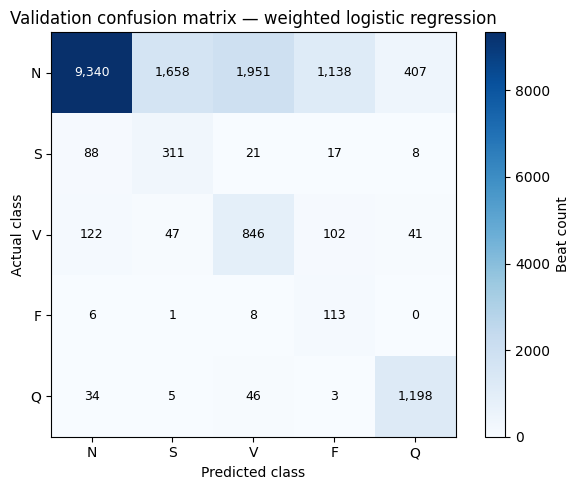

In [23]:
fig, ax = plt.subplots(figsize=(6.5, 5))
image = ax.imshow(val_cm, cmap='Blues')
ax.set(xticks=np.arange(5), yticks=np.arange(5),
       xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
       xlabel='Predicted class', ylabel='Actual class',
       title='Validation confusion matrix — weighted logistic regression')
for row in range(5):
    for col in range(5):
        ax.text(col, row, f'{val_cm[row, col]:,}', ha='center', va='center',
                color='white' if val_cm[row, col] > val_cm.max() / 2 else 'black',
                fontsize=9)
fig.colorbar(image, ax=ax, label='Beat count')
plt.tight_layout()
plt.show()

**Interpret the validation results before continuing:**

1. Compare the two models' **macro F1** and **balanced accuracy**, not only accuracy.
2. Which class has the lowest sensitivity? How many of its beats were actually in validation (`support_beats`)?
3. In the confusion matrix, find one common error by reading an **actual** row across to a **predicted** column.
4. If rare-class recall improves but precision falls, describe the trade-off as more incorrect alerts. The correct trade-off for a clinical workflow cannot be set from these beat-level CSVs alone.

## 7. Train a small 1D convolutional neural network

**Why this model?** The 187 inputs have an order: nearby values describe a short stretch of the same electrical signal. A 1D convolution slides a small set of learned weights along those values to detect local shapes. Unlike logistic regression, stacked convolutions can combine nearby patterns nonlinearly. This is a practical next experiment, not a guarantee of a higher score. [PyTorch Conv1d documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv1d.html) · [source ECG paper](https://arxiv.org/pdf/1805.00794).

| Stage | Tensor shape for one batch | What it does |
|---|---|---|
| Input | `(batch, 1, 187)` | One signal channel, 187 ordered positions |
| Convolution + pooling | shorter sequence, 16 then 32 channels | Learn local waveform patterns and reduce sequence length |
| Convolution + pooling | shorter sequence, 64 channels | Combine local patterns |
| Dense output | `(batch, 5)` | One score for each beat label |

The CNN receives the **same processed values** as logistic regression, reshaped from `(rows, 187)` to `(rows, 1, 187)` for PyTorch. No new signal processing is performed.

**What is weighted cross-entropy?** Cross-entropy penalizes the model when it assigns a low probability to the correct class. For a beat whose true class is $y$, its loss is $-w_y\log(p_y)$, where $p_y$ is the model's probability for that class and $w_y$ is its class weight. A larger weight makes that beat's error count more during training. PyTorch's `CrossEntropyLoss` accepts the five raw class scores and computes the probability-based loss internally.

**Why use it here?** The fit subset has many more N beats than some other labels, so an unweighted loss can be dominated by the common class. We set each class weight proportional to $1/\sqrt{n_c}$, where $n_c$ is that class's fit-subset count, then normalize the weights to mean 1. This gives rarer classes more influence without full inverse-frequency weighting. We compare validation macro F1, sensitivity, and precision to see the trade-off; these weights are a modeling choice, not a measure of clinical severity.

In [24]:
import copy
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__, '| training device:', DEVICE)

def beat_tensor(X):
    # Conv1d expects (batch, channels, ordered signal positions).
    return torch.from_numpy(np.ascontiguousarray(X[:, np.newaxis, :], dtype=np.float32))

fit_dataset = TensorDataset(beat_tensor(X_fit), torch.from_numpy(y_fit.astype(np.int64)))
val_dataset = TensorDataset(beat_tensor(X_val), torch.from_numpy(y_val.astype(np.int64)))
BATCH_SIZE = 256
train_loader = DataLoader(fit_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED), num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
def predict_from_loader(model, loader):
    model.eval()
    predictions = []
    with torch.inference_mode():
        for xb, _ in loader:
            predictions.append(model(xb.to(DEVICE)).argmax(dim=1).cpu().numpy())
    return np.concatenate(predictions)

# counts how many beats of each class are in the fit dataset
fit_counts = np.bincount(y_fit, minlength=5)
# class_weights are computed as the inverse of the square root of the counts
class_weights = 1 / np.sqrt(fit_counts.astype(np.float32))
# normalize the weights so that their mean is 1
class_weights /= class_weights.mean()
display(pd.DataFrame({'class': CLASS_NAMES, 'fit_beats': fit_counts,
                      'CNN_loss_weight': class_weights}).round(3))
print('One CNN input batch shape:', next(iter(train_loader))[0].shape)

PyTorch: 2.10.0+cu128 | training device: cuda


,class,fit_beats,CNN_loss_weight
0,N,57977,0.206
1,S,1778,1.178
2,V,4630,0.730
3,F,513,2.193
4,Q,5145,0.693


One CNN input batch shape: torch.Size([256, 1, 187])


### Define and train the network

For Conv1d and MaxPool1d (with the default ceil_mode=False), the output length is:

$$
L_{\mathrm{out}} = \left\lfloor \frac{L_{\mathrm{in}} + 2P - D(K-1) - 1}{S} + 1 \right\rfloor
$$

Here $L_{\mathrm{in}}$ is the input length, $K$ the kernel size, $P$ the padding on each side, $S$ the stride, and $D$ the dilation. The floor brackets mean round down. Conv1d outputs (batch, out_channels, L_out); MaxPool1d keeps the channel count and outputs (batch, channels, L_out).

The training loss is **cross-entropy**, which penalizes low scores for the correct class. The weights above scale each class's contribution. After every epoch, we compute validation macro F1 and keep the weights from the best epoch. **Early stopping** ends training after three epochs without improvement. `MAX_EPOCHS` is a CPU-friendly upper bound; a Kaggle GPU can speed up the same code. The test file is still unopened.

The validation set is used for model selection, so its score is an internal estimate. Training is stochastic even with a fixed seed; GPU runs can differ slightly.

In [25]:
class SmallECGCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Conv1d uses (batch, channels, positions); input is (batch, 1, 187).
        self.features = nn.Sequential(
            # Conv 1: (batch, 1, 187) -> (batch, 16, 187); padding keeps the length.
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=7, padding=3), 
            nn.ReLU(),
            # Pool 1: (batch, 16, 187) -> (batch, 16, 93); length halves, rounding down.
            nn.MaxPool1d(kernel_size=2),
            # Conv 2: (batch, 16, 93) -> (batch, 32, 93).
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, padding=2), 
            nn.ReLU(),
            # Pool 2: (batch, 32, 93) -> (batch, 32, 46).
            nn.MaxPool1d(kernel_size=2),
            # Conv 3: (batch, 32, 46) -> (batch, 64, 46).
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1), 
            nn.ReLU(),
            # Pool 3: (batch, 64, 46) -> (batch, 64, 23).
            nn.MaxPool1d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            # Flatten: (batch, 64, 23) -> (batch, 64 * 23).
            nn.Flatten(), 
            # Dense layer: (batch, 64 * 23) -> (batch, 64).
            nn.Linear(64 * 23, 64), 
            nn.ReLU(),
            nn.Dropout(0.2), 
            # Output layer: (batch, 64) -> (batch, 5 class scores).
            nn.Linear(64, 5),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn = SmallECGCNN().to(DEVICE)
loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, device=DEVICE))
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
print(cnn)
print('Trainable parameters:', sum(p.numel() for p in cnn.parameters() if p.requires_grad))

SmallECGCNN(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1472, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=5, bias=True)
  )
)
Trainable parameters: 103525


In [26]:
MAX_EPOCHS = 8
PATIENCE = 3
with tracked_run(
    '1D CNN',
    {
        'architecture': '3 Conv1d blocks + dense classifier',
        'optimizer': 'Adam',
        'learning_rate': 1e-3,
        'batch_size': BATCH_SIZE,
        'max_epochs': MAX_EPOCHS,
        'patience': PATIENCE,
        'loss': 'weighted cross entropy',
        'class_weight_rule': 'inverse sqrt fit count',
    },
) as run:
    history = []
    best_macro_f1 = -1.0
    best_epoch = 0
    best_state = None
    stale_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        cnn.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(cnn(xb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(yb)

        cnn.eval()
        val_predictions = []
        with torch.inference_mode():
            for xb, _ in val_loader:
                val_predictions.append(cnn(xb.to(DEVICE)).argmax(dim=1).cpu().numpy())
        epoch_val_pred = np.concatenate(val_predictions)
        epoch_macro_f1 = f1_score(y_val, epoch_val_pred, labels=CLASS_IDS,
                                  average='macro', zero_division=0)
        history.append({'epoch': epoch, 'train_weighted_loss': running_loss / len(y_fit),
                        'val_macro_F1': epoch_macro_f1,
                        'val_accuracy': accuracy_score(y_val, epoch_val_pred)})
        print(f'Epoch {epoch:2d}: loss={history[-1]["train_weighted_loss"]:.4f}, '
              f'val macro F1={epoch_macro_f1:.3f}, '
              f'val accuracy={history[-1]["val_accuracy"]:.3f}')

        if run is not None:
            run.log({
                'epoch': epoch,
                'train/weighted_loss': history[-1]['train_weighted_loss'],
                'val/macro_F1': history[-1]['val_macro_F1'],
                'val/accuracy': history[-1]['val_accuracy'],
                'val/balanced_accuracy': balanced_accuracy_score(y_val, epoch_val_pred),
            })

        if epoch_macro_f1 > best_macro_f1:
            best_macro_f1 = epoch_macro_f1
            best_epoch = epoch
            best_state = copy.deepcopy(cnn.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= PATIENCE:
                print('Early stopping: no validation macro F1 improvement for', PATIENCE, 'epochs.')
                break

    cnn.load_state_dict(best_state)
    cnn.eval()
    print('Restored best epoch:', best_epoch, '| validation macro F1:', round(best_macro_f1, 3))

    if run is not None:
        best_validation_predictions = predict_from_loader(cnn, val_loader)
        run.summary.update(validation_tracking_metrics(y_val, best_validation_predictions))
        run.summary['best_epoch'] = best_epoch

Epoch  1: loss=0.7876, val macro F1=0.739, val accuracy=0.933
Epoch  2: loss=0.4333, val macro F1=0.752, val accuracy=0.937
Epoch  3: loss=0.3496, val macro F1=0.805, val accuracy=0.955
Epoch  4: loss=0.3065, val macro F1=0.808, val accuracy=0.953
Epoch  5: loss=0.2802, val macro F1=0.814, val accuracy=0.959
Epoch  6: loss=0.2573, val macro F1=0.797, val accuracy=0.957
Epoch  7: loss=0.2383, val macro F1=0.825, val accuracy=0.959
Epoch  8: loss=0.2307, val macro F1=0.829, val accuracy=0.964
Restored best epoch: 8 | validation macro F1: 0.829


epoch,▁▂▃▄▅▆▇█
train/weighted_loss,█▄▂▂▂▁▁▁
val/accuracy,▁▂▆▅▇▆▇█
val/balanced_accuracy,▁▅▅▆▇▇██
val/macro_F1,▁▂▆▆▇▅██
best_epoch,8
epoch,8
train/weighted_loss,0.23073
val/F1_F,0.56749
val/F1_N,0.981
val/F1_Q,0.97121


,epoch,train_weighted_loss,val_macro_F1,val_accuracy
0,1,0.788,0.739,0.933
1,2,0.433,0.752,0.937
2,3,0.350,0.805,0.955
3,4,0.306,0.808,0.953
4,5,0.280,0.814,0.959
5,6,0.257,0.797,0.957
6,7,0.238,0.825,0.959
7,8,0.231,0.829,0.964


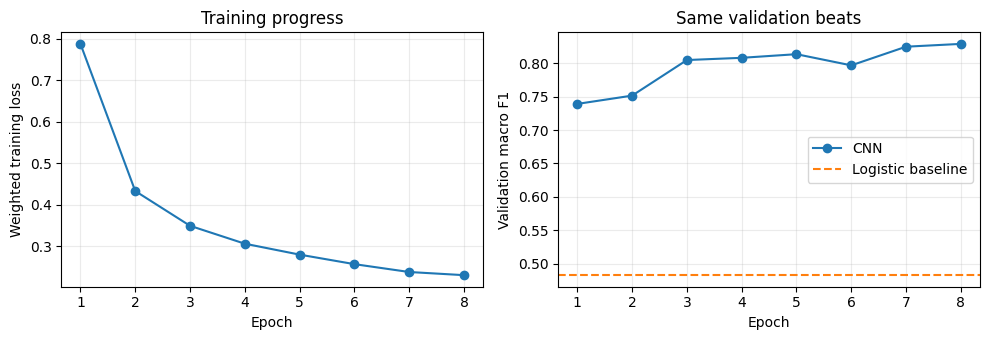

In [27]:
history_df = pd.DataFrame(history)
display(history_df.round(3))
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history_df['epoch'], history_df['train_weighted_loss'], marker='o')
axes[0].set(xlabel='Epoch', ylabel='Weighted training loss', title='Training progress')
axes[1].plot(history_df['epoch'], history_df['val_macro_F1'], marker='o', label='CNN')
axes[1].axhline(validation_summary.loc['Weighted logistic regression', 'macro_F1'],
                color='tab:orange', linestyle='--', label='Logistic baseline')
axes[1].set(xlabel='Epoch', ylabel='Validation macro F1', title='Same validation beats')
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Train a plain LSTM on the same beats

A **long short-term memory (LSTM)** network reads a sequence one value at a time and updates an internal memory. Here, the sequence is the **187 measurements within one extracted beat**. Each row is not a sequence of 187 heartbeats; the CSV contains no ordering of consecutive beats. [PyTorch LSTM](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html) · [dataset card](https://www.kaggle.com/datasets/shayanfazeli/heartbeat).

| Model | Input tensor | How its beat summary is made |
|---|---|---|
| 1D CNN | (batch, 1, 187) | Learned filters scan local waveform shapes |
| Plain LSTM | (batch, 187, 1) | The mean of its hidden states summarizes ordered samples |

This LSTM has **one layer and one direction**, with no attention. It uses the CNN's fit/validation beats, class weights, batch size, and validation macro F1 rule. A final hidden state would be dominated by the end of the beat, which can be zero-padded. We average hidden states across positions instead. Padding may still affect this average. The CSV does not provide verified unpadded lengths, so we do not infer a mask from exact zeros.

In [28]:
class PlainECGLSTM(nn.Module):
    def __init__(self, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size,
                            num_layers=1, batch_first=True)
        self.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(hidden_size, 5))

    def forward(self, x):
        # Shared loader: (batch, 1, 187); LSTM: (batch, 187, 1).
        sequence = x.transpose(1, 2)
        states, _ = self.lstm(sequence)
        beat_summary = states.mean(dim=1)  # fixed average; no attention weights
        return self.classifier(beat_summary)

torch.manual_seed(SEED + 1)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED + 1)
lstm_model = PlainECGLSTM().to(DEVICE)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
lstm_train_loader = DataLoader(
    fit_dataset, batch_size=BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(SEED), num_workers=0,
)
print(lstm_model)
print('Trainable parameters:', sum(p.numel() for p in lstm_model.parameters() if p.requires_grad))
example_batch, _ = next(iter(val_loader))
print('LSTM input shape:', example_batch.transpose(1, 2).shape)
print('Output shape:', lstm_model(example_batch[:2].to(DEVICE)).shape)

PlainECGLSTM(
  (lstm): LSTM(1, 64, batch_first=True)
  (classifier): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=64, out_features=5, bias=True)
  )
)
Trainable parameters: 17477
LSTM input shape: torch.Size([256, 187, 1])
Output shape: torch.Size([2, 5])


### Fit the LSTM and keep its best validation epoch

We use the **same weighted cross-entropy** as the CNN. After each epoch, we evaluate all validation beats and retain the epoch with the highest **macro F1**. The maximum of eight epochs and patience of three match the CNN experiment. This is an architectural comparison, not a claim that the two models have identical parameter counts or training time. The test file is not used here.

In [29]:
with tracked_run(
    'Plain LSTM',
    {
        'architecture': '1-layer unidirectional LSTM + mean pooling',
        'hidden_size': 64,
        'optimizer': 'Adam',
        'learning_rate': 1e-3,
        'batch_size': BATCH_SIZE,
        'max_epochs': MAX_EPOCHS,
        'patience': PATIENCE,
        'loss': 'weighted cross entropy',
        'class_weight_rule': 'inverse sqrt fit count',
    },
) as run:
    lstm_history = []
    lstm_best_f1 = -1.0
    lstm_best_epoch = 0
    lstm_best_state = None
    lstm_stale_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        lstm_model.train()
        running_loss = 0.0
        for xb, yb in lstm_train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            lstm_optimizer.zero_grad()
            loss = loss_fn(lstm_model(xb), yb)
            loss.backward()
            lstm_optimizer.step()
            running_loss += loss.item() * len(yb)
        lstm_model.eval()
        predictions = []
        with torch.inference_mode():
            for xb, _ in val_loader:
                predictions.append(lstm_model(xb.to(DEVICE)).argmax(dim=1).cpu().numpy())
        epoch_pred = np.concatenate(predictions)
        epoch_f1 = f1_score(y_val, epoch_pred, labels=CLASS_IDS,
                            average='macro', zero_division=0)
        lstm_history.append({
            'epoch': epoch, 'train_weighted_loss': running_loss / len(y_fit),
            'val_macro_F1': epoch_f1,
            'val_accuracy': accuracy_score(y_val, epoch_pred),
        })
        print(f'Epoch {epoch:2d}: loss={lstm_history[-1]["train_weighted_loss"]:.4f}, '
              f'val macro F1={epoch_f1:.3f}, '
              f'val accuracy={lstm_history[-1]["val_accuracy"]:.3f}')
        if run is not None:
            run.log({
                'epoch': epoch,
                'train/weighted_loss': lstm_history[-1]['train_weighted_loss'],
                'val/macro_F1': lstm_history[-1]['val_macro_F1'],
                'val/accuracy': lstm_history[-1]['val_accuracy'],
                'val/balanced_accuracy': balanced_accuracy_score(y_val, epoch_pred),
            })

        if epoch_f1 > lstm_best_f1:
            lstm_best_f1 = epoch_f1
            lstm_best_epoch = epoch
            lstm_best_state = copy.deepcopy(lstm_model.state_dict())
            lstm_stale_epochs = 0
        else:
            lstm_stale_epochs += 1
            if lstm_stale_epochs >= PATIENCE:
                print('Early stopping: no validation macro F1 improvement for', PATIENCE, 'epochs.')
                break

    lstm_model.load_state_dict(lstm_best_state)
    lstm_model.eval()
    print('Restored best epoch:', lstm_best_epoch,
          '| validation macro F1:', round(lstm_best_f1, 3))

    if run is not None:
        best_validation_predictions = predict_from_loader(lstm_model, val_loader)
        run.summary.update(validation_tracking_metrics(y_val, best_validation_predictions))
        run.summary['best_epoch'] = lstm_best_epoch

Epoch  1: loss=1.2983, val macro F1=0.181, val accuracy=0.828
Epoch  2: loss=1.2666, val macro F1=0.233, val accuracy=0.746
Epoch  3: loss=1.1789, val macro F1=0.246, val accuracy=0.783
Epoch  4: loss=1.1823, val macro F1=0.181, val accuracy=0.828
Epoch  5: loss=1.1447, val macro F1=0.181, val accuracy=0.828
Epoch  6: loss=1.1358, val macro F1=0.181, val accuracy=0.828
Early stopping: no validation macro F1 improvement for 3 epochs.
Restored best epoch: 3 | validation macro F1: 0.246


epoch,▁▂▄▅▇█
train/weighted_loss,█▇▃▃▁▁
val/accuracy,█▁▄███
val/balanced_accuracy,▁▇█▁▁▁
val/macro_F1,▁▇█▁▁▁
best_epoch,3
epoch,6
train/weighted_loss,1.13578
val/F1_F,0
val/F1_N,0.89231
val/F1_Q,0


,epoch,train_weighted_loss,val_macro_F1,val_accuracy
0,1,1.298,0.181,0.828
1,2,1.267,0.233,0.746
2,3,1.179,0.246,0.783
3,4,1.182,0.181,0.828
4,5,1.145,0.181,0.828
5,6,1.136,0.181,0.828


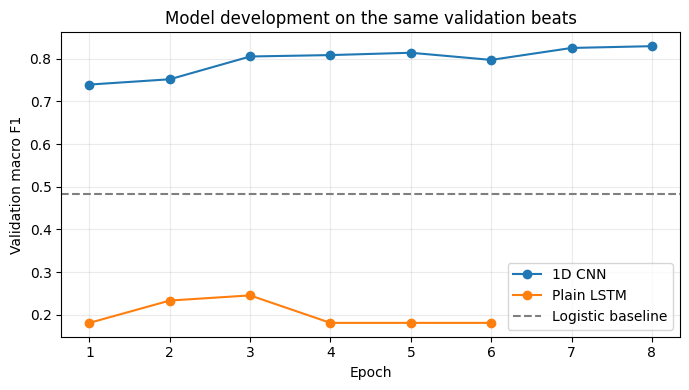

In [30]:
lstm_history_df = pd.DataFrame(lstm_history)
display(lstm_history_df.round(3))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_df['epoch'], history_df['val_macro_F1'], marker='o', label='1D CNN')
ax.plot(lstm_history_df['epoch'], lstm_history_df['val_macro_F1'], marker='o', label='Plain LSTM')
ax.axhline(validation_summary.loc['Weighted logistic regression', 'macro_F1'],
           color='tab:gray', linestyle='--', label='Logistic baseline')
ax.set(xlabel='Epoch', ylabel='Validation macro F1',
       title='Model development on the same validation beats')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

### Interpret this run before changing the architecture

In the **saved Kaggle GPU run**, the CNN reached **0.835 validation macro F1** and the plain LSTM reached **0.246**. The LSTM predicted only N or V: its validation sensitivity was **0** for S, F, and Q. Its accuracy still appeared substantial because N is common.

This is a failure of this particular LSTM setup on this validation split, **not proof that all LSTMs are unsuitable for ECG**. Possible contributors include the long zero-padded sequence, a simple averaged summary, and the limited training setup; these have not been isolated experimentally. Keep any next architecture changes within model development, and do not choose them using the supplied test result.

## 9. Train a CNN–Transformer encoder

**Question:** Can attention across learned waveform features improve on the small CNN?

1. The **CNN front end** uses the same three convolution and pooling blocks as the earlier CNN. It turns each beat from `(batch, 1, 187)` into `(batch, 64, 23)` features. Its weights are trained from scratch for this model; it does not reuse the fitted CNN's weights.
2. We transpose the result to **23 ordered tokens**, each with 64 features: `(batch, 23, 64)`. A learned positional vector tells the encoder which part of the beat each token came from.
3. A **Transformer encoder** uses self-attention so each token can combine information from other positions in the *same beat*. Two independently initialized encoder layers each use four attention heads. We average the final token states and map them to five class scores. [PyTorch TransformerEncoderLayer](https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html).

| Model | What it combines | Information available |
|---|---|---|
| 1D CNN | Local waveform shapes through stacked filters | One processed beat |
| Plain LSTM | Ordered samples through recurrent states | One processed beat |
| CNN–Transformer | Local CNN shapes, then attention across 23 feature positions | One processed beat |

**Limits:** Attention does not recover neighboring heartbeats or heart rhythm; those are absent from each CSV row. The processed beats may have zero padding, but the file does not provide verified unpadded lengths. We therefore do **not** guess an attention mask from zero values. The encoder can still attend to padded regions. This is a model-development experiment, not a clinical test.

In [ ]:
class CNNTransformerECG(nn.Module):
    def __init__(self):
        super().__init__()
        # CNN front end: same three Conv1d -> ReLU -> MaxPool blocks as SmallECGCNN.
        # (batch, 1, 187) -> (batch, 64, 23). Calling SmallECGCNN() creates fresh,
        # untrained weights; its classifier is discarded and only .features is kept.
        self.features = SmallECGCNN().features
        # Learned positional embedding: one 64-value vector per token position.
        # Self-attention ignores order on its own, so this tells the encoder where
        # in the beat each of the 23 tokens came from. Shape (1, 23, 64) broadcasts
        # across the batch; small random start values (std 0.02).
        self.position = nn.Parameter(torch.zeros(1, 23, 64))
        nn.init.normal_(self.position, std=0.02)
        # Two Transformer encoder layers. Each layer applies:
        #   x = LayerNorm(x + SelfAttention(x))     # mix information across tokens
        #   x = LayerNorm(x + FeedForward(x))       # 64 -> 128 -> 64 per token, GELU
        # d_model=64 matches the CNN channels; nhead=4 gives four 16-value heads.
        # batch_first=True means inputs are (batch, tokens, features).
        # Construct each layer separately so its initial weights are independent.
        self.encoder_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=64, nhead=4, dim_feedforward=128,
                dropout=0.1, activation='gelu', batch_first=True,
            )
            for _ in range(2)
        ])
        # Normalizes the averaged beat summary before the classifier.
        self.norm = nn.LayerNorm(64)
        # Classifier head: (batch, 64) -> (batch, 5 class scores).
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(64, 5))

    def forward(self, x):
        # CNN features: (batch, 1, 187) -> (batch, 64, 23).
        # Transpose to tokens: (batch, 64, 23) -> (batch, 23, 64), i.e. 23 positions
        # along the beat, each described by 64 learned features.
        tokens = self.features(x).transpose(1, 2)
        # Add position information: shape stays (batch, 23, 64).
        tokens = tokens + self.position
        # Self-attention lets each token use the other 22 tokens of the same beat.
        # No padding mask is passed: true unpadded lengths are not available.
        # Shape stays (batch, 23, 64) after each layer.
        for layer in self.encoder_layers:
            tokens = layer(tokens)
        # Average the 23 contextual tokens into one summary: (batch, 23, 64) -> (batch, 64).
        beat_summary = self.norm(tokens.mean(dim=1))
        # Raw class scores (logits); CrossEntropyLoss applies softmax during training.
        return self.head(beat_summary)

torch.manual_seed(SEED + 2)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED + 2)
cnn_transformer = CNNTransformerECG().to(DEVICE)
cnn_transformer_optimizer = torch.optim.Adam(cnn_transformer.parameters(), lr=1e-3)
cnn_transformer_train_loader = DataLoader(
    fit_dataset, batch_size=BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(SEED), num_workers=0,
)
print('CNN–Transformer input:', next(iter(val_loader))[0].shape)
print('CNN–Transformer output:',
      cnn_transformer(next(iter(val_loader))[0][:2].to(DEVICE)).shape)
print('Trainable parameters:',
      sum(p.numel() for p in cnn_transformer.parameters() if p.requires_grad))

CNN–Transformer input: torch.Size([256, 1, 187])
CNN–Transformer output: torch.Size([2, 5])
Trainable parameters: 77797


### Fit and inspect the CNN–Transformer

The model uses the **same fit and validation beats**, inverse-square-root class weights, batch size, Adam learning rate, eight-epoch maximum, and three-epoch patience as the CNN. Its feature extractor and attention layers are trained together. We restore the epoch with the highest validation macro F1 and log this model as a separate W&B run when tracking is enabled.

After training, compare **macro F1**, balanced accuracy, and the sensitivity and precision of S, F, and Q. A higher validation score would justify further study, not establish superiority on new patients. The supplied test file remains outside this experiment.

In [34]:
with tracked_run(
    'CNN–Transformer',
    {
        'architecture': '3 Conv1d blocks + 2 Transformer encoder layers',
        'model_seed': SEED + 2,
        'feature_tokens': 23,
        'd_model': 64,
        'attention_heads': 4,
        'encoder_layers': 2,
        'optimizer': 'Adam',
        'learning_rate': 1e-3,
        'batch_size': BATCH_SIZE,
        'max_epochs': MAX_EPOCHS,
        'patience': PATIENCE,
        'loss': 'weighted cross entropy',
        'class_weight_rule': 'inverse sqrt fit count',
    },
) as run:
    cnn_transformer_history = []
    cnn_transformer_best_f1 = -1.0
    cnn_transformer_best_epoch = 0
    cnn_transformer_best_state = None
    cnn_transformer_stale_epochs = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        cnn_transformer.train()
        running_loss = 0.0
        for xb, yb in cnn_transformer_train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            cnn_transformer_optimizer.zero_grad()
            loss = loss_fn(cnn_transformer(xb), yb)
            loss.backward()
            cnn_transformer_optimizer.step()
            running_loss += loss.item() * len(yb)

        epoch_pred = predict_from_loader(cnn_transformer, val_loader)
        epoch_f1 = f1_score(y_val, epoch_pred, labels=CLASS_IDS,
                            average='macro', zero_division=0)
        cnn_transformer_history.append({
            'epoch': epoch,
            'train_weighted_loss': running_loss / len(y_fit),
            'val_macro_F1': epoch_f1,
            'val_accuracy': accuracy_score(y_val, epoch_pred),
        })
        print(f'Epoch {epoch:2d}: '
              f'loss={cnn_transformer_history[-1]["train_weighted_loss"]:.4f}, '
              f'val macro F1={epoch_f1:.3f}, '
              f'val accuracy={cnn_transformer_history[-1]["val_accuracy"]:.3f}')
        if run is not None:
            run.log({
                'epoch': epoch,
                'train/weighted_loss': cnn_transformer_history[-1]['train_weighted_loss'],
                'val/macro_F1': epoch_f1,
                'val/accuracy': cnn_transformer_history[-1]['val_accuracy'],
                'val/balanced_accuracy': balanced_accuracy_score(y_val, epoch_pred),
            })

        if epoch_f1 > cnn_transformer_best_f1:
            cnn_transformer_best_f1 = epoch_f1
            cnn_transformer_best_epoch = epoch
            cnn_transformer_best_state = copy.deepcopy(cnn_transformer.state_dict())
            cnn_transformer_stale_epochs = 0
        else:
            cnn_transformer_stale_epochs += 1
            if cnn_transformer_stale_epochs >= PATIENCE:
                print('Early stopping: no validation macro F1 improvement for',
                      PATIENCE, 'epochs.')
                break

    cnn_transformer.load_state_dict(cnn_transformer_best_state)
    cnn_transformer.eval()
    print('Restored best epoch:', cnn_transformer_best_epoch,
          '| validation macro F1:', round(cnn_transformer_best_f1, 3))
    if run is not None:
        best_validation_predictions = predict_from_loader(cnn_transformer, val_loader)
        run.summary.update(validation_tracking_metrics(y_val, best_validation_predictions))
        run.summary['best_epoch'] = cnn_transformer_best_epoch

Epoch  1: loss=0.7665, val macro F1=0.780, val accuracy=0.955
Epoch  2: loss=0.3215, val macro F1=0.836, val accuracy=0.963
Epoch  3: loss=0.2629, val macro F1=0.844, val accuracy=0.966
Epoch  4: loss=0.2288, val macro F1=0.842, val accuracy=0.967
Epoch  5: loss=0.2049, val macro F1=0.843, val accuracy=0.967
Epoch  6: loss=0.1890, val macro F1=0.889, val accuracy=0.974
Epoch  7: loss=0.1756, val macro F1=0.854, val accuracy=0.967
Epoch  8: loss=0.1691, val macro F1=0.870, val accuracy=0.970
Restored best epoch: 6 | validation macro F1: 0.889


epoch,▁▂▃▄▅▆▇█
train/weighted_loss,█▃▂▂▁▁▁▁
val/accuracy,▁▄▅▆▆█▅▇
val/balanced_accuracy,▁▅▆▇▇▇██
val/macro_F1,▁▅▅▅▅█▆▇
best_epoch,6
epoch,8
train/weighted_loss,0.16907
val/F1_F,0.79352
val/F1_N,0.98586
val/F1_Q,0.95943


,epoch,train_weighted_loss,val_macro_F1,val_accuracy
0,1,0.766,0.780,0.955
1,2,0.321,0.836,0.963
2,3,0.263,0.844,0.966
3,4,0.229,0.842,0.967
4,5,0.205,0.843,0.967
5,6,0.189,0.889,0.974
6,7,0.176,0.854,0.967
7,8,0.169,0.870,0.970


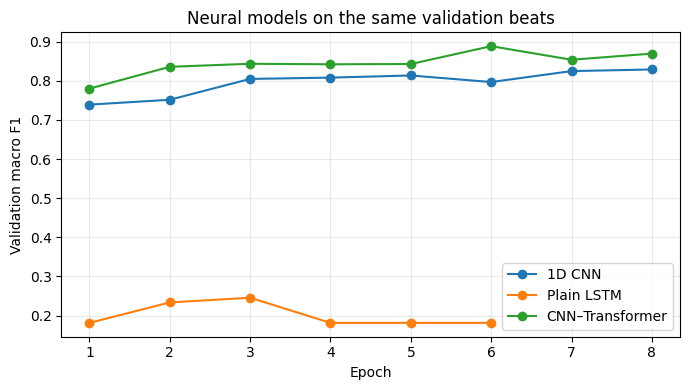

In [35]:
cnn_transformer_history_df = pd.DataFrame(cnn_transformer_history)
display(cnn_transformer_history_df.round(3))
fig, ax = plt.subplots(figsize=(7, 4))
for name, model_history in [
    ('1D CNN', history_df),
    ('Plain LSTM', lstm_history_df),
    ('CNN–Transformer', cnn_transformer_history_df),
]:
    ax.plot(model_history['epoch'], model_history['val_macro_F1'],
            marker='o', label=name)
ax.set(xlabel='Epoch', ylabel='Validation macro F1',
       title='Neural models on the same validation beats')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Compare the CNN, LSTM, CNN–Transformer, and baselines

All five models use the **same validation beats**. Compare macro F1 and balanced accuracy, then inspect each class's precision and sensitivity. The best epoch was chosen on these same beats, so the scores are model-development results. Look for changes in S and F errors before concluding that one neural network is more promising for further study.

In [36]:
def predict_neural_model(model, X, batch_size=BATCH_SIZE):
    loader = DataLoader(beat_tensor(X), batch_size=batch_size,
                        shuffle=False, num_workers=0)
    model.eval()
    predictions = []
    with torch.inference_mode():
        for xb in loader:
            predictions.append(model(xb.to(DEVICE)).argmax(dim=1).cpu().numpy())
    return np.concatenate(predictions)

cnn_val_pred = predict_neural_model(cnn, X_val)
lstm_val_pred = predict_neural_model(lstm_model, X_val)
cnn_transformer_val_pred = predict_neural_model(cnn_transformer, X_val)
comparison = pd.DataFrame([
    summary_row('Always majority class', y_val, dummy_val_pred),
    summary_row('Weighted logistic regression', y_val, linear_val_pred),
    summary_row('1D CNN', y_val, cnn_val_pred),
    summary_row('Plain LSTM', y_val, lstm_val_pred),
    summary_row('CNN–Transformer', y_val, cnn_transformer_val_pred),
]).set_index('model')
display(comparison.round(3))
for model_name, pred in [('1D CNN', cnn_val_pred), ('Plain LSTM', lstm_val_pred),
                         ('CNN–Transformer', cnn_transformer_val_pred)]:
    print(model_name, '— per-class validation metrics')
    table, matrix = class_metrics(y_val, pred)
    display(table.round(3))
    display(pd.DataFrame(matrix, index=[f'Actual {x}' for x in CLASS_NAMES],
                         columns=[f'Predicted {x}' for x in CLASS_NAMES]))

,accuracy,balanced_accuracy,macro_F1
model,,,
Always majority class,0.828,0.200,0.181
Weighted logistic regression,0.674,0.778,0.483
1D CNN,0.964,0.881,0.829
Plain LSTM,0.783,0.293,0.246
CNN–Transformer,0.974,0.886,0.889


1D CNN — per-class validation metrics


,class,support_beats,precision_PPV,recall_sensitivity,F1,specificity,NPV
0,N,14494,0.988,0.974,0.981,0.941,0.885
1,S,445,0.734,0.708,0.721,0.993,0.992
2,V,1158,0.880,0.933,0.906,0.991,0.995
3,F,128,0.438,0.805,0.567,0.992,0.999
4,Q,1286,0.959,0.984,0.971,0.997,0.999


,Predicted N,Predicted S,Predicted V,Predicted F,Predicted Q
Actual N,14124,112,114,102,42
Actual S,109,315,16,1,4
Actual V,40,2,1080,28,8
Actual F,15,0,10,103,0
Actual Q,13,0,7,1,1265


Plain LSTM — per-class validation metrics


,class,support_beats,precision_PPV,recall_sensitivity,F1,specificity,NPV
0,N,14494,0.884,0.901,0.892,0.431,0.475
1,S,445,0.000,0.000,0.000,1.000,0.975
2,V,1158,0.239,0.564,0.335,0.873,0.966
3,F,128,0.000,0.000,0.000,1.000,0.993
4,Q,1286,0.000,0.000,0.000,1.000,0.927


,Predicted N,Predicted S,Predicted V,Predicted F,Predicted Q
Actual N,13058,0,1436,0,0
Actual S,423,0,22,0,0
Actual V,505,0,653,0,0
Actual F,121,0,7,0,0
Actual Q,667,0,619,0,0


CNN–Transformer — per-class validation metrics


,class,support_beats,precision_PPV,recall_sensitivity,F1,specificity,NPV
0,N,14494,0.988,0.984,0.986,0.944,0.923
1,S,445,0.800,0.755,0.777,0.995,0.994
2,V,1158,0.923,0.934,0.928,0.994,0.995
3,F,128,0.824,0.766,0.794,0.999,0.998
4,Q,1286,0.928,0.993,0.959,0.994,0.999


,Predicted N,Predicted S,Predicted V,Predicted F,Predicted Q
Actual N,14255,83,70,13,73
Actual S,96,336,7,0,6
Actual V,48,1,1081,8,20
Actual F,17,0,13,98,0
Actual Q,9,0,0,0,1277


## 11. Reproduce the existing CNN test benchmark

The CNN was selected and its supplied test result was viewed **before** the LSTM and CNN–Transformer experiments. This cell reproduces that fixed CNN result so the notebook remains runnable from top to bottom. We do **not** switch to the LSTM or CNN–Transformer based on test results or present a new LSTM or CNN–Transformer test score as independent confirmation.

Use the validation comparison above to decide what to study next. A patient-separated or external holdout would be needed for a fresh final assessment after iterative model development.

In [37]:
test_df = pd.read_csv(DATA_DIR / 'mitbih_test.csv', header=None, dtype=np.float32)
X_test, y_test = split_signal_and_label(test_df, 'test')
print(f'Supplied test file: {test_df.shape}')
test_pred = predict_neural_model(cnn, X_test)
display(pd.DataFrame([summary_row('1D CNN — existing test benchmark', y_test, test_pred)]).round(3))
test_class_metrics, test_cm = class_metrics(y_test, test_pred)
display(test_class_metrics.round(3))
display(pd.DataFrame(test_cm, index=[f'Actual {x}' for x in CLASS_NAMES],
                     columns=[f'Predicted {x}' for x in CLASS_NAMES]))

Supplied test file: (21892, 188)


,model,accuracy,balanced_accuracy,macro_F1
0,1D CNN — existing test benchmark,0.962,0.866,0.821


,class,support_beats,precision_PPV,recall_sensitivity,F1,specificity,NPV
0,N,18118,0.985,0.974,0.979,0.928,0.881
1,S,556,0.733,0.665,0.697,0.994,0.991
2,V,1448,0.871,0.929,0.899,0.990,0.995
3,F,162,0.440,0.790,0.565,0.992,0.998
4,Q,1608,0.957,0.972,0.965,0.997,0.998


,Predicted N,Predicted S,Predicted V,Predicted F,Predicted Q
Actual N,17647,131,161,122,57
Actual S,167,370,15,3,1
Actual V,51,3,1345,37,12
Actual F,24,0,10,128,0
Actual Q,29,1,14,1,1563


## 12. What did the model comparison establish?

1. **Majority reference:** high accuracy can conceal a complete failure on S, V, F, and Q.
2. **Within-beat patterns:** the CNN scans local shapes; the plain LSTM averages its hidden states; the CNN–Transformer applies attention across learned feature positions. Compare validation macro F1 and per-class errors to see what each learned.
3. **Padding limit:** the 187 positions include possible zero padding. The LSTM averages across the full sequence, and the CNN–Transformer has no verified padding mask; true unpadded lengths are not supplied.
4. **Unequal error costs:** class-weighted loss changes the precision–recall trade-off; model outputs are not clinical alert thresholds.
5. **Validation limit:** patient and recording IDs are absent. Neither split proves performance on new patients. The test result above belongs to the previously selected CNN; the LSTM and CNN–Transformer experiments need a fresh independent holdout for confirmatory comparison.

**Review questions:** Does the CNN–Transformer beat the CNN on validation macro F1? Which of S or F has the larger sensitivity change? Did higher sensitivity cost precision? What would you need to know about the original beat boundaries before masking padded positions?

**Sources:** [Kaggle processed dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat) · [Kachuee et al. source paper](https://arxiv.org/pdf/1805.00794) · [PhysioNet MIT-BIH database](https://physionet.org/content/mitdb/1.0.0/) · [PyTorch LSTM](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html) · [scikit-learn evaluation guide](https://scikit-learn.org/stable/modules/model_evaluation.html). · [PyTorch TransformerEncoderLayer](https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html)